In [55]:
import torch
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device: ", device)

device:  cuda


In [50]:
model_seg = YOLO("model/model_seg.pt")
model_dect = YOLO(r".\model\model_detect.pt")


image 1/1 c:\Users\1tram\OneDrive\Documents\KLTN-NAM\data\detection-task\images\train\Duong_7_cam_1_1.png: 384x640 1 Lane, 169.3ms
Speed: 3.6ms preprocess, 169.3ms inference, 6.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\Users\1tram\OneDrive\Documents\KLTN-NAM\data\detection-task\images\train\Duong_7_cam_1_1.png: 288x512 6 xe_mays, 1 xe_bus, 17.9ms
Speed: 1.3ms preprocess, 17.9ms inference, 1.2ms postprocess per image at shape (1, 3, 288, 512)


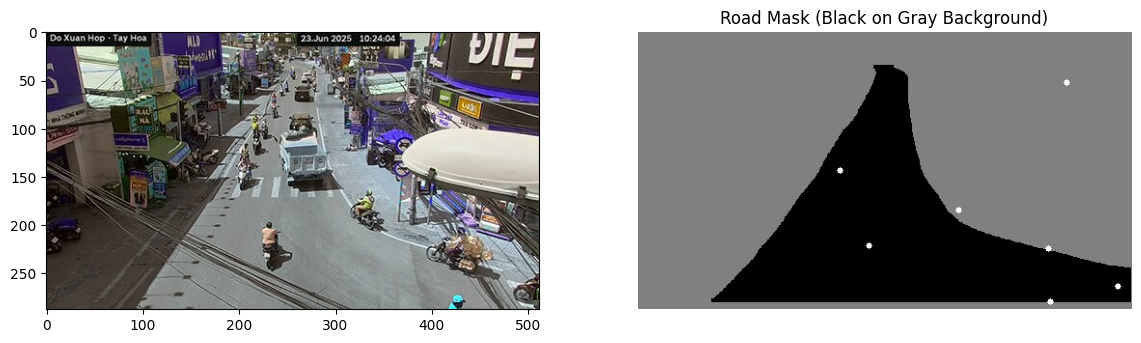

In [53]:
img_path = r"data\detection-task\images\train\Duong_7_cam_1_1.png"

road = model_seg.predict(source=img_path,
                         device = device,
                         save = False,
                         show = True)
obj = model_dect(source=img_path, device=device, save=False, show=False)[0]


road_mask = road[0].masks.data.cpu().numpy()
road_mask = np.sum(road_mask, axis=0)
road_mask = (road_mask > 0.5).astype(np.uint8)

img = cv2.imread(img_path)
h, w, _ = img.shape

# resize
road_mask = cv2.resize(road_mask, (w, h), interpolation=cv2.INTER_NEAREST)

background = np.full((h, w, 3), 128, dtype=np.uint8)
background[road_mask == 1] = (0, 0, 0)

background_rgb = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)

for box in obj.boxes.xyxy:
        x1, y1, x2, y2 = box.int().tolist()
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
        cv2.circle(background_rgb, (cx, cy), 3, (255, 255, 255), -1)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.imshow(background_rgb)

plt.axis("off")
plt.title("Road Mask (Black on Gray Background)")
plt.show()


In [63]:
def make_base_input(img_path):
    road = model_seg.predict(source=img_path, device = device, save = False, show = True)
    obj = model_dect(source=img_path, device=device, save=False, show=False)[0]
    
    road_mask = road[0].masks.data.cpu().numpy()
    road_mask = np.sum(road_mask, axis=0)
    road_mask = (road_mask > 0.5).astype(np.uint8)

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    # resize
    road_mask = cv2.resize(road_mask, (w, h), interpolation=cv2.INTER_NEAREST)

    background = np.full((h, w, 3), 128, dtype=np.uint8)
    background[road_mask == 1] = (0, 0, 0)

    background_rgb = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)

    for box in obj.boxes.xyxy:
            x1, y1, x2, y2 = box.int().tolist()
            cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
            cv2.circle(background_rgb, (cx, cy), 3, (255, 255, 255), -1)
            
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.subplot(1, 2, 2)
    plt.imshow(background_rgb)

    plt.axis("off")
    plt.title("Base Downstream-task Input-image")
    plt.show()
    
def loop_show(folder_path : str, max_items = 5):
    n_range = range(1, 11)
    m_list = [1, 2]
    i_range = range(0, 40)
    
    ns = random.choices(n_range, k=max_items)
    for n in ns:
        m = random.choice(m_list)
        i = random.choice(i_range)
        
        file_name = f"Duong_{n}_cam_{m}_{i}.png"
        file_path = folder_path + "/" + file_name
        
        make_base_input(file_path)


image 1/1 c:\Users\1tram\OneDrive\Documents\KLTN-NAM\data\detection-task\images\train\Duong_6_cam_2_7.png: 384x640 1 Lane, 200.9ms
Speed: 6.3ms preprocess, 200.9ms inference, 12.7ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\Users\1tram\OneDrive\Documents\KLTN-NAM\data\detection-task\images\train\Duong_6_cam_2_7.png: 288x512 11 xe_mays, 14.7ms
Speed: 1.3ms preprocess, 14.7ms inference, 1.4ms postprocess per image at shape (1, 3, 288, 512)


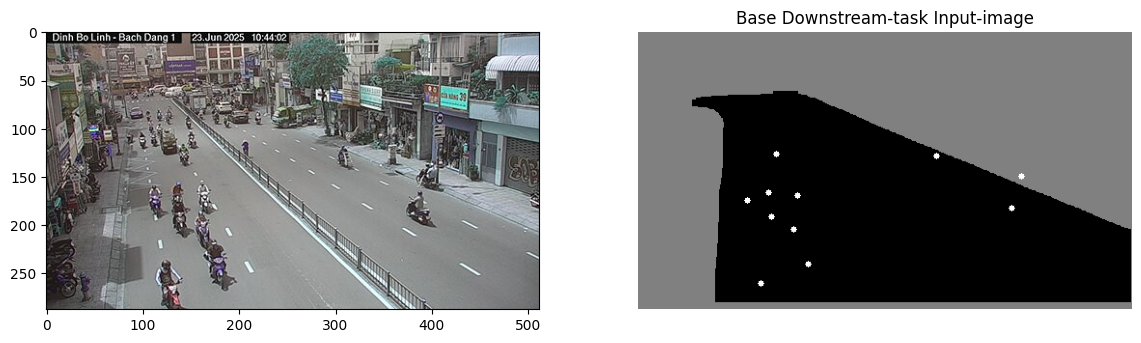


image 1/1 c:\Users\1tram\OneDrive\Documents\KLTN-NAM\data\detection-task\images\train\Duong_5_cam_1_7.png: 384x640 1 Lane, 27.3ms
Speed: 3.1ms preprocess, 27.3ms inference, 8.7ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\Users\1tram\OneDrive\Documents\KLTN-NAM\data\detection-task\images\train\Duong_5_cam_1_7.png: 288x512 8 xe_mays, 6 xe_otos, 15.6ms
Speed: 1.2ms preprocess, 15.6ms inference, 0.9ms postprocess per image at shape (1, 3, 288, 512)


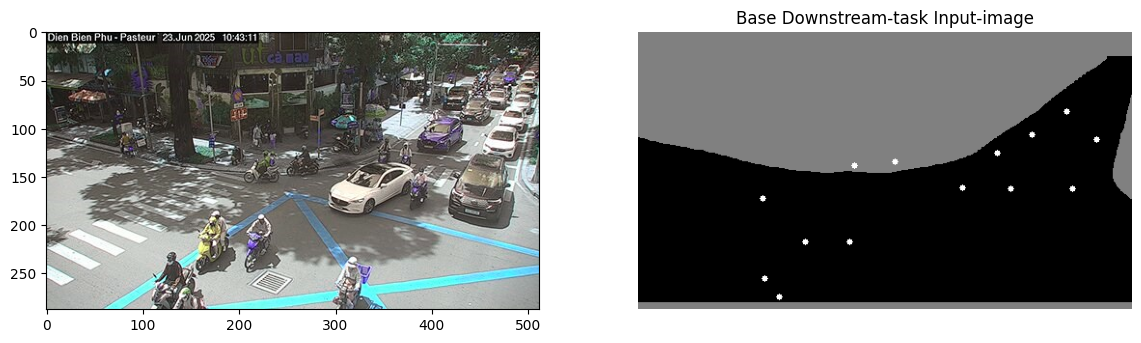


image 1/1 c:\Users\1tram\OneDrive\Documents\KLTN-NAM\data\detection-task\images\train\Duong_3_cam_1_16.png: 384x640 1 Lane, 80.2ms
Speed: 2.0ms preprocess, 80.2ms inference, 16.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\Users\1tram\OneDrive\Documents\KLTN-NAM\data\detection-task\images\train\Duong_3_cam_1_16.png: 288x512 13 xe_mays, 3 xe_otos, 2 xe_tais, 16.9ms
Speed: 1.3ms preprocess, 16.9ms inference, 1.0ms postprocess per image at shape (1, 3, 288, 512)


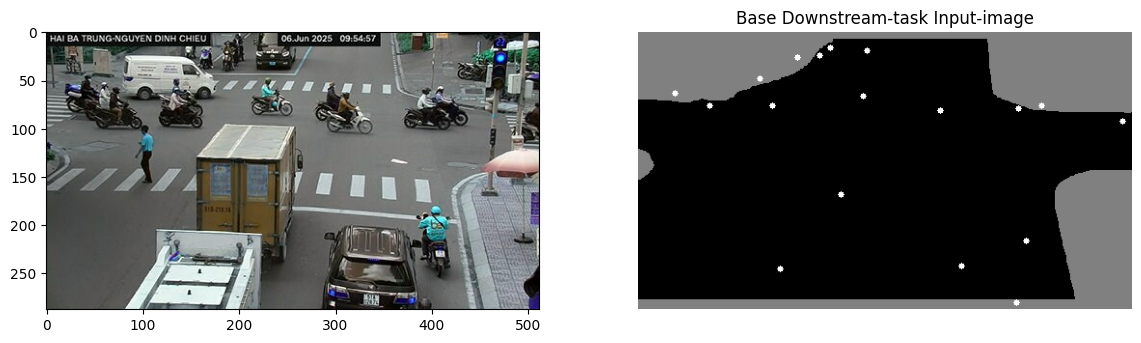

In [64]:
loop_show("data/detection-task/images/train", max_items=3)